<a href="https://colab.research.google.com/github/ida-jk/Test1-25.05.2026/blob/main/Test_1_Comp_v.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

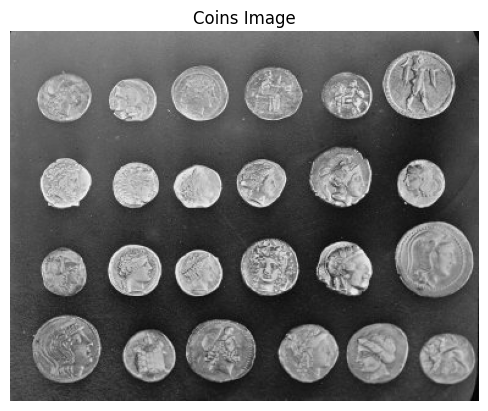

Image size (height, width): (303, 384)
Minimum grayscale level: 1
Maximum grayscale level: 252


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_uint
from skimage.util import random_noise
from skimage.filters import gaussian, prewitt
from skimage.data import binary_blobs
from skimage.morphology import erosion, disk
from skimage.color import rgb2gray
from scipy import ndimage
import math

# Task 1: Load the 'coins' image
coins = data.coins()

# Visualize the image
plt.imshow(coins, cmap='gray')
plt.title("Coins Image")
plt.axis('off')
plt.show()

# Report the image size
print("Image size (height, width):", coins.shape)

# Report the grayscale pixel range
print("Minimum grayscale level:", np.min(coins))
print("Maximum grayscale level:", np.max(coins))

 2.Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

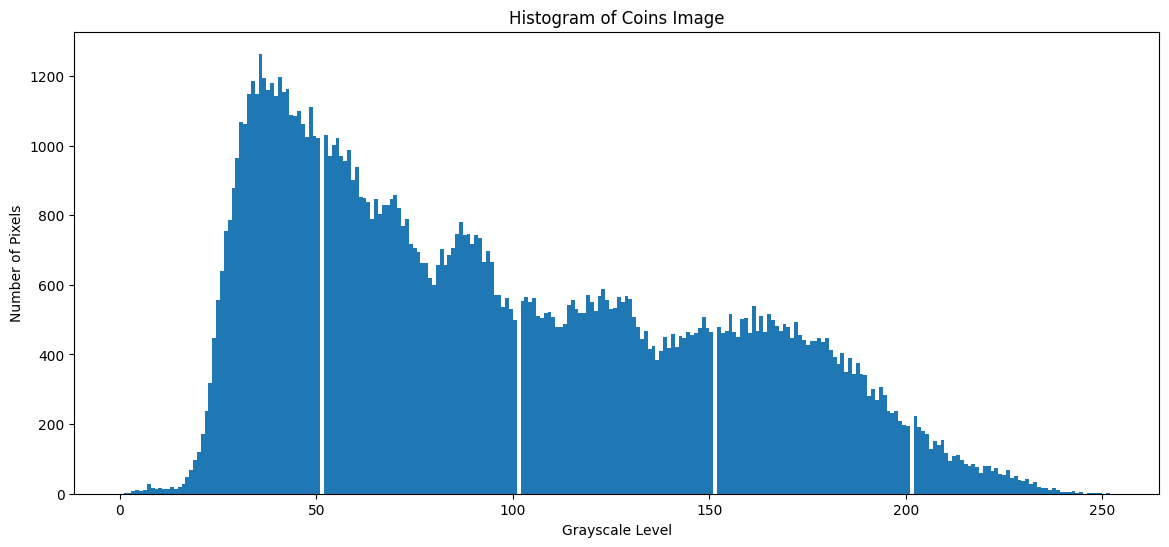

In [2]:
# Load the 'coins' image
coins = data.coins()

# Reshape the image into a 1D array
v = coins.reshape(coins.shape[0] * coins.shape[1], 1)

# Plot the histogram
fig = plt.figure(figsize=(14, 6))
plt.hist(v, bins=256, density=False)
plt.title("Histogram of Coins Image")
plt.xlabel("Grayscale Level")
plt.ylabel("Number of Pixels")
plt.show()

Left side (dark grayscale values near 0–80):
Represents the darker regions of the image.

Middle grayscale values (around 80–180):
Represents medium gray regions.
textured parts of the coins

Right side (bright grayscale values near 180–255):
Represents brighter regions.

3. Applied noise to the image and use the correct function to erase the noise.

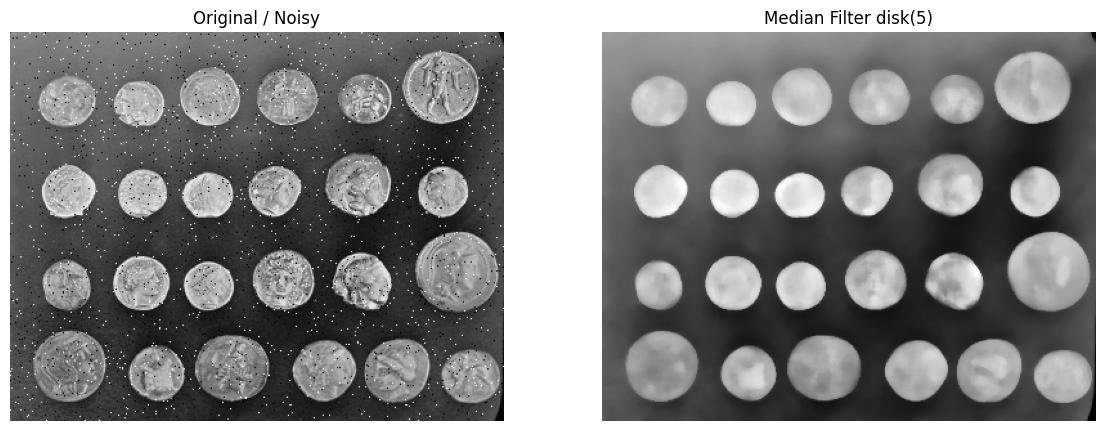

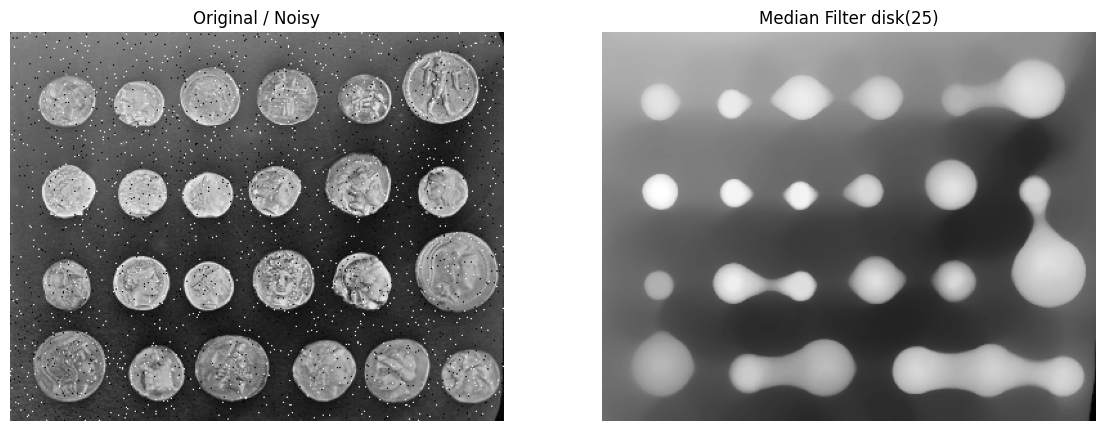

In [5]:

from skimage import data, img_as_ubyte
from skimage.morphology import disk
from skimage.filters import median

# Load the 'coins' image
img = data.coins()

# Add Salt & Pepper noise
noise = np.random.random(img.shape)

noisy_image = img_as_ubyte(img)

# Add white pixels (salt)
noisy_image[noise > 0.99] = 255

# Add black pixels (pepper)
noisy_image[noise < 0.01] = 0


# Function to compare images
def plot_comparison(original, filtered, filter_name):

    fig, (ax1, ax2) = plt.subplots(
        ncols=2,
        figsize=(14, 6),
        sharex=True,
        sharey=True
    )

    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('Original / Noisy')
    ax1.axis('off')

    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')


# -------- Median Filter 5x5 --------
sel5 = disk(5)
img_med5x5 = median(noisy_image, sel5)

plot_comparison(noisy_image, img_med5x5, 'Median Filter disk(5)')
plt.show()


# -------- Median Filter 25x25 --------
sel25 = disk(25)
img_med25x25 = median(noisy_image, sel25)

plot_comparison(noisy_image, img_med25x25, 'Median Filter disk(25)')
plt.show()

4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

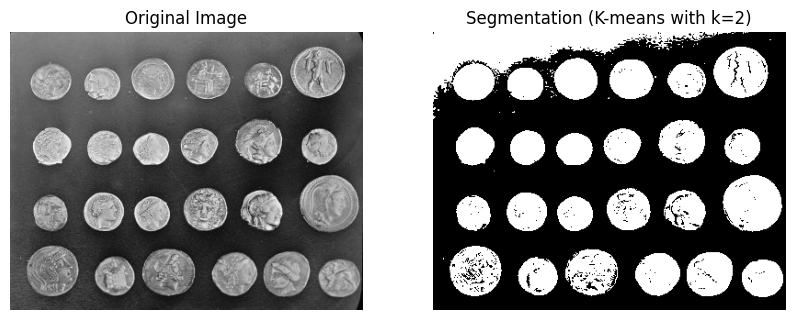

In [6]:

import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from skimage import data
import numpy as np

# Load the 'coins' image
I = data.coins()

# Reshape image into a 1D vector for K-means
v_I = I.reshape(I.shape[0] * I.shape[1], 1)

# Fit K-means clustering with 2 clusters
n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)

# Predict cluster labels
v_kmeans = kmeans.predict(v_I)

# Reshape result back into image form
I_kmeans = np.reshape(v_kmeans, (I.shape[0], I.shape[1]))

# Display original and segmented images
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

# Original image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.set_axis_off()

# Segmented image
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(I_kmeans, cmap=plt.cm.gray)
ax2.set_title('Segmentation (K-means with k=2)')
ax2.set_axis_off()

plt.show()

5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

Number of coins detected: 96


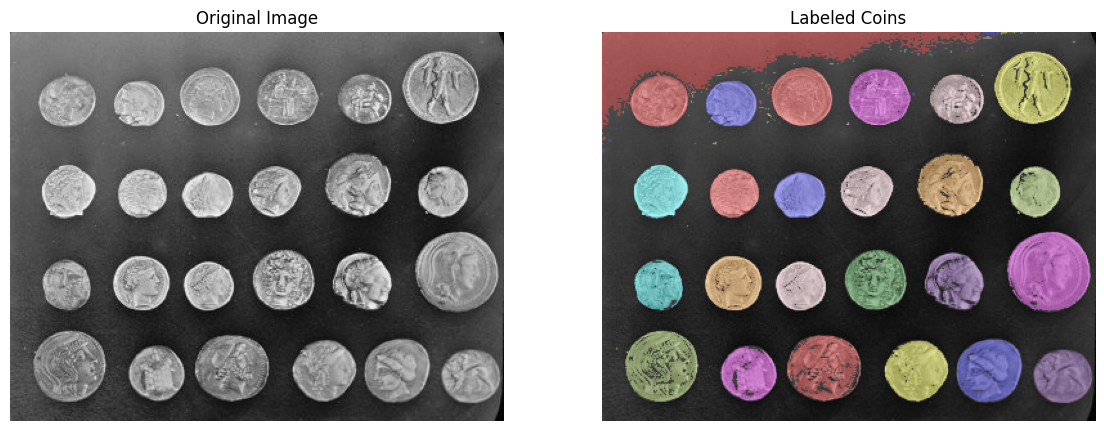

In [7]:

from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb
import numpy as np

# Load the 'coins' image
I = data.coins()

# -------- Step 1: Segment the image --------
# Apply Otsu thresholding
thresh = threshold_otsu(I)

# Create binary image
binary = I > thresh


# -------- Step 2: Label connected objects --------
labeled_image = label(binary)


# -------- Step 3: Count objects --------
num_coins = labeled_image.max()

print("Number of coins detected:", num_coins)


# -------- Step 4: Create colored labeled image --------
label_image_rgb = label2rgb(labeled_image, image=I, bg_label=0)


# -------- Step 5: Display results --------
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2)

# Original image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(I, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

# Labeled image
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(label_image_rgb)
ax2.set_title('Labeled Coins')
ax2.axis('off')

plt.show()

6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.

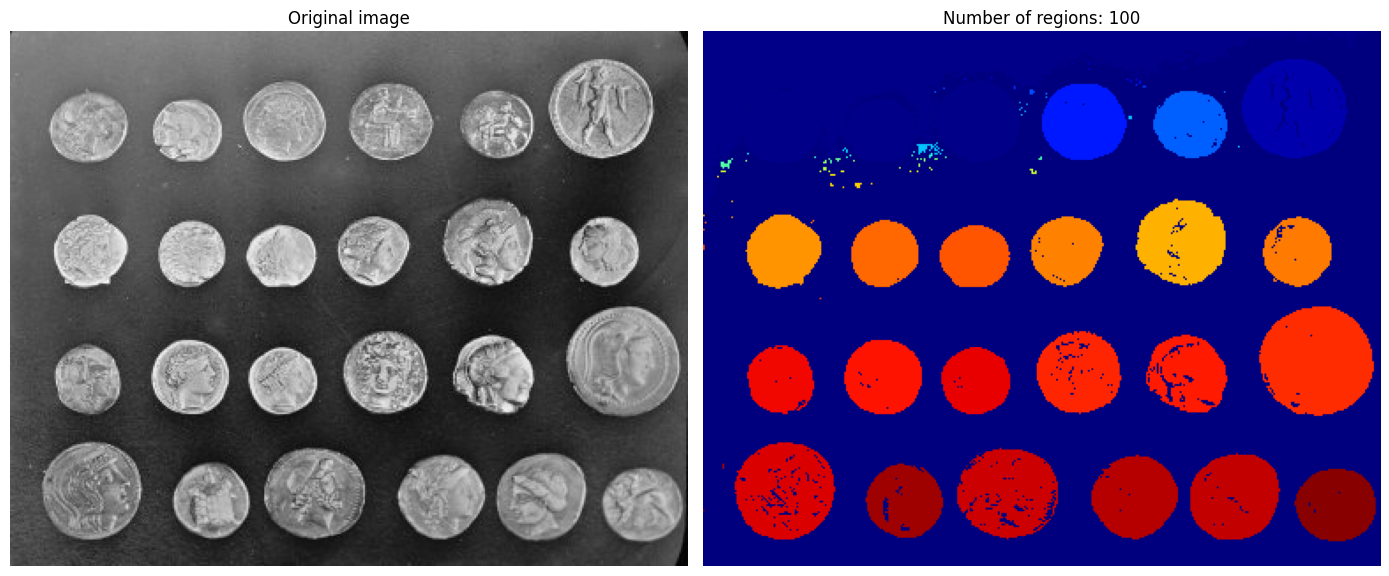

--- Average Values of Extracted Features ---
Average Area: 488.64 pixels
Average Major Axis Length: 14.09 pixels
Average Orientation: -0.32 radians
--------------------------------------------


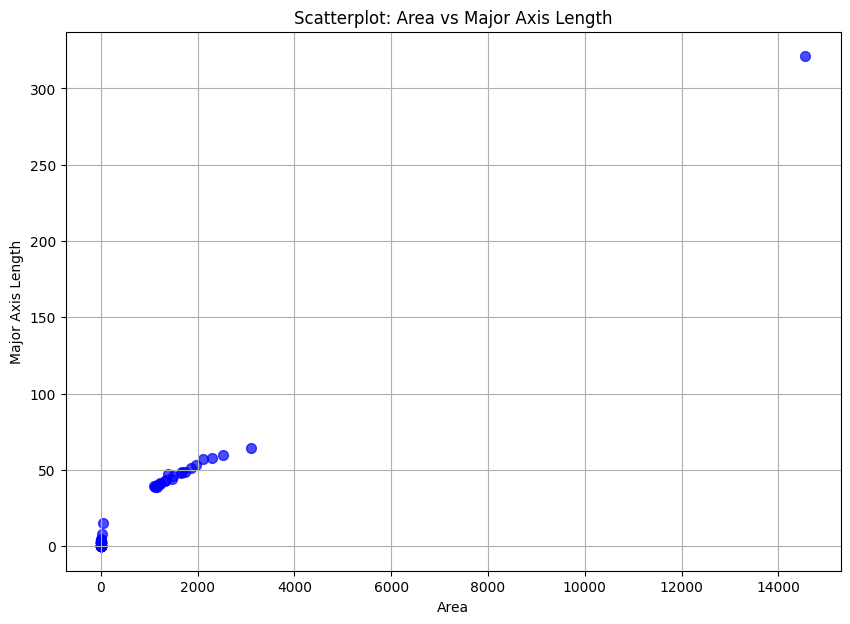

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage import data  # Imported to load the built-in dataset

# 1. Load and visualize the 'coins' image from skimage built-in datasets
I = data.coins()

# 2. Segment the image (Thresholding to create binary mask)
# Built-in coins image has a grey background; thresholding at 100 separates them
bw = I > 100

# Label image regions:
label_image, nregions = label(bw, return_num=True)

# Segmentation figure:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(I, cmap=plt.cm.gray) # Show original coins image
ax[0].set_title('Original image')
ax[1].imshow(label_image, cmap=plt.cm.jet)
ax[1].set_title('Number of regions: {}'.format(nregions))
ax[0].set_axis_off()
ax[1].set_axis_off()
plt.tight_layout()
plt.show()

# Get regional properties:
props = regionprops(label_image)

# Allocate matrix for the 3 requested features: Area, Major Axis Length, Orientation
features = np.zeros((nregions, 3))

# Extract the correct features requested by the prompt
for i in range(0, nregions):
    features[i, 0] = props[i].area
    features[i, 1] = props[i].major_axis_length
    features[i, 2] = props[i].orientation

# 3. Calculate and report the average values
avg_area = np.mean(features[:, 0])
avg_major_axis = np.mean(features[:, 1])
avg_orientation = np.mean(features[:, 2])

print("--- Average Values of Extracted Features ---")
print("Average Area: {:.2f} pixels".format(avg_area))
print("Average Major Axis Length: {:.2f} pixels".format(avg_major_axis))
print("Average Orientation: {:.2f} radians".format(avg_orientation))
print("--------------------------------------------")

# 4. Represent a scatterplot of the area vs major axis length
fig = plt.figure(figsize=(10, 7))
plt.scatter(features[:, 0], features[:, 1], s=50, c='blue', marker='o', alpha=0.7)
plt.xlabel('Area')
plt.ylabel('Major Axis Length')
plt.title('Scatterplot: Area vs Major Axis Length')
plt.grid(True)
plt.show()


7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [9]:
from skimage.measure import regionprops
import numpy as np

# 1. Obtain regional properties using regionprops
props = regionprops(label_image)

# 2. Filter regions with an area greater than 1750 pixels and count them
large_coin_count = 0

print("--- Filtering Regions (Area > 1750 pixels) ---")
for ireg in range(0, nregions):
    region_area = props[ireg].area

    # Check if the region meets your threshold criteria
    if region_area > 1750:
        large_coin_count += 1
        print('Region {} is kept: Area = {} pixels'.format(ireg + 1, region_area))

# 3. Report the final count requested by the prompt
print("\nFinal Count: There are {} coins with an area greater than 1750 pixels.".format(large_coin_count))


--- Filtering Regions (Area > 1750 pixels) ---
Region 1 is kept: Area = 14558.0 pixels
Region 4 is kept: Area = 2514.0 pixels
Region 72 is kept: Area = 1867.0 pixels
Region 86 is kept: Area = 3108.0 pixels
Region 92 is kept: Area = 2304.0 pixels
Region 93 is kept: Area = 2119.0 pixels
Region 94 is kept: Area = 1958.0 pixels

Final Count: There are 7 coins with an area greater than 1750 pixels.


8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

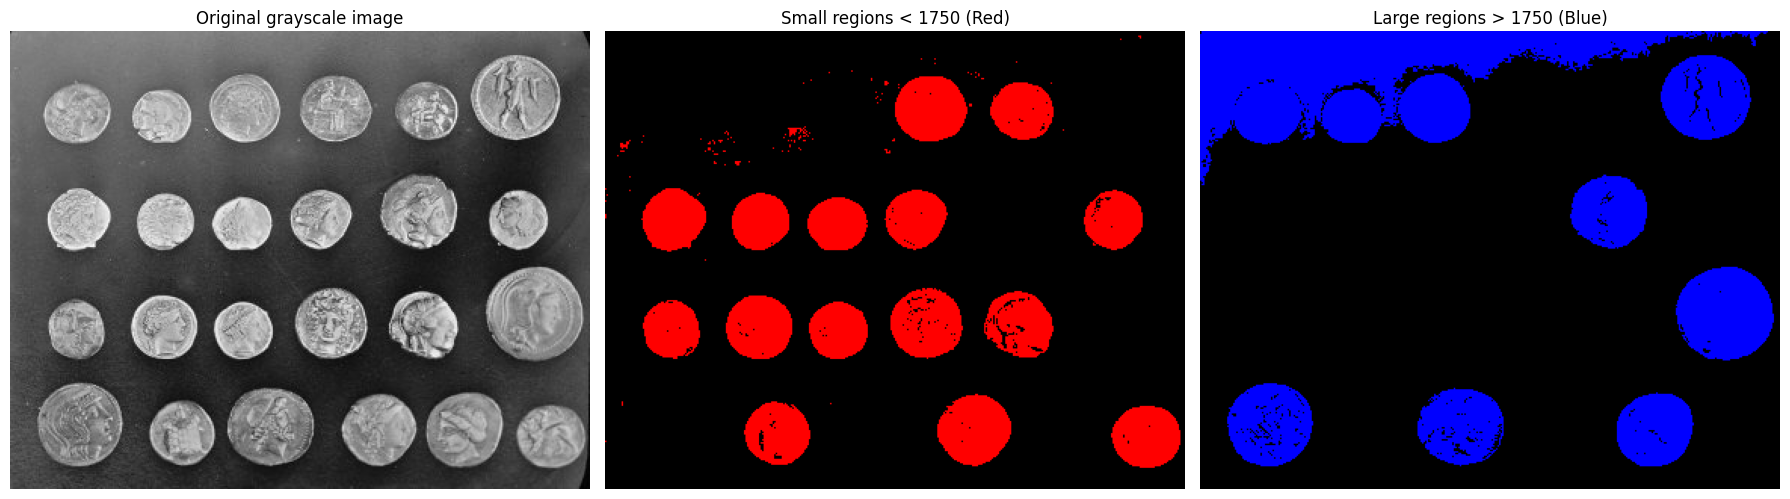

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data  # Implemented to load the built-in dataset
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# --- 1. LOAD THE BUILT-IN COINS IMAGE AND SET UP VARIABLES ---
I = data.coins()
IG = I.squeeze()  # This defines the variable 'IG' using the built-in coins dataset

# Thresholding the built-in dataset (background is dark/gray, coins are light)
bw = IG > 100
label_image, nregions = label(bw, return_num=True)
props = regionprops(label_image)

# --- 2. IDENTIFY INDICES USING YOUR NOTEBOOK LOGIC ---
area = np.zeros(nregions)
for i in range(0, nregions):
    area[i] = props[i].area

ind_large = np.where(area >= 1750)
ind_small = np.where(area < 1750)

# --- 3. FILTER SMALL AND LARGE COINS ---
label_image_small = label_image.copy()
label_image_large = label_image.copy()

# Filter out large regions by re-labeling them as background (0)
for i in np.squeeze(ind_large):
    iregion = i + 1
    label_image_small[label_image_small == iregion] = 0

# Filter out small regions by re-labeling them as background (0)
for i in np.squeeze(ind_small):
    iregion = i + 1
    label_image_large[label_image_large == iregion] = 0

# --- 4. GENERATE COLOR OVERLAYS ---
image_label_overlay_small = label2rgb(label_image_small, colors=['red'], bg_label=0)
image_label_overlay_large = label2rgb(label_image_large, colors=['blue'], bg_label=0)

# --- 5. GENERATE THE 3-PANEL FIGURE ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

# Panel 1: Original Image
ax[0].imshow(IG, cmap=plt.cm.gray)
ax[0].set_title('Original grayscale image')

# Panel 2: Small Coins Image (Red)
ax[1].imshow(image_label_overlay_small)
ax[1].set_title('Small regions < 1750 (Red)')

# Panel 3: Big Coins Image (Blue)
ax[2].imshow(image_label_overlay_large)
ax[2].set_title('Large regions > 1750 (Blue)')

# Turn off axes borders for all three panels cleanly
ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

plt.tight_layout()
plt.show()



 9. Describe the main steps required to perform segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)
 1.Flattening: Reshape the 3D RGB image array (Height, Width, 3) into a 2D pixel array (N_pixels, 3 Color Features) so the model can process it.Function: pixels = img.reshape(-1, 3)
2.Clustering: Initialize the Gaussian Mixture Model with your chosen number of color clusters and fit it to predict group labels for every pixel.Function: labels = GaussianMixture(n_components=K).fit_predict(pixels)
3.Reshaping: Map the 1D list of predicted cluster labels back into the original 2D dimensions of your image.Function: segmented_img = labels.reshape(height, width)
4.Visualizing: Display the reconstructed 2D label map using a colormap to inspect the segmented regions.Function: plt.imshow(segmented_img, cmap='jet')

10. Extract the main texture features of this image

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops

# 1. Load and visualize the 'coins' image from the skimage built-in datasets
I_raw = data.coins()
IG = I_raw.squeeze()  # Ensure it is a 2D grayscale image

# 2. Segment and label regions, then clear noise using your < 1750 rule
bw = IG > 100
label_image, nregions_raw = label(bw, return_num=True)

# Generate an initial props list to find noise locations
initial_props = regionprops(label_image)
area = np.array([p.area for p in initial_props])
ind_small = np.where(area < 1750)

# Clear background noise artifacts out of the label map using your loop style
for i in np.squeeze(ind_small):
    iregion = i + 1
    label_image[label_image == iregion] = 0

# 3. Obtain regional properties after removal of spurious regions
# We explicitly pass intensity_image=IG to extract texture from inside the bounding box
props = regionprops(label_image, intensity_image=IG)
nregions = len(props)

# 4. Extract the regional texture features using your template loop
iregion = 0
props_texture = np.zeros((nregions, 5))

for p in props:
    # Extract the bounding box coordinates for the current coin
    minr, minc, maxr, maxc = p.bbox

    # Crop out the grayscale texture snippet corresponding to this specific object
    # Note: Using standard slice matrix mapping matching your variable bounds
    I_crop = IG[minr:maxr, minc:maxc]

    # Compute the GLCM for this region (distance=1, angle=0, levels=256 for standard uint8)
    g = graycomatrix(I_crop, [1], [0], levels=256, normed=True, symmetric=True)

    # Calculate the five requested texture properties
    contrast = graycoprops(g, 'contrast')[0, 0]
    dissimilarity = graycoprops(g, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(g, 'homogeneity')[0, 0]
    energy = graycoprops(g, 'energy')[0, 0]
    correlation = graycoprops(g, 'correlation')[0, 0]

    # Save to your output matrix tracker array
    props_texture[iregion, 0] = contrast
    props_texture[iregion, 1] = dissimilarity
    props_texture[iregion, 2] = homogeneity
    props_texture[iregion, 3] = energy
    props_texture[iregion, 4] = correlation

    iregion = iregion + 1

# 5. Export to Excel file and display dataframe matching your template output
df = pd.DataFrame(props_texture, columns=['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation'])
df.to_excel("Texture_features.xlsx", index=False)

# Display the final texture dataframe table
print(df)


     Contrast  Dissimilarity  Homogeneity    Energy  Correlation
0  248.846170       7.181699     0.315645  0.028269     0.925268
1  995.526634      21.321429     0.086937  0.017297     0.765693
2  874.402041      19.271429     0.079270  0.018208     0.851993
3  459.778478      13.575857     0.123772  0.019072     0.891341
4  614.473377      17.424675     0.075056  0.017743     0.769254
5  513.121909      15.408997     0.094019  0.019040     0.872599
6  368.987347      11.719592     0.123555  0.022191     0.903246
